# Q15.
```{admonition}
:class: note
This problem involves the `Boston` data set. We will now try to predict per capita crime rate using the other variables in this data set. In other words, per capita crime rate is the response, and the other variables are the predictors.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import subplots
from ISLP.models import summarize

In [2]:
boston = pd.read_csv('../../../ALL CSV FILES - 2nd Edition/Boston.csv')
boston = boston.drop(columns = boston.columns[0])

In [3]:
boston.sample(3)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
162,1.83377,0.0,19.58,1,0.605,7.802,98.2,2.0407,5,403,14.7,1.92,50.0
315,0.25356,0.0,9.90,0,0.544,5.705,77.7,3.9450,4,304,18.4,11.50,16.2
194,0.01439,60.0,2.93,0,0.401,6.604,18.8,6.2196,1,265,15.6,4.38,29.1


## (a)
```{admonition}
:class: note
For each predictor, fit a simple linear regression model to predict the response. Describe your results. In which of the models is there a statistically significant association between the predictor and the response? Create some plots to back up your assertions.

In [4]:
one_var_models = {}
for predictor in boston.columns[1:]:
    one_var_models[predictor] = smf.ols(formula = f'crim ~ {predictor}',data=boston).fit()
    print(f'Model predicting crime rate using {predictor}')
    print(summarize(one_var_models[predictor]))
    print()

Model predicting crime rate using zn
             coef  std err       t  P>|t|
Intercept  4.4537    0.417  10.675    0.0
zn        -0.0739    0.016  -4.594    0.0

Model predicting crime rate using indus
             coef  std err      t  P>|t|
Intercept -2.0637    0.667 -3.093  0.002
indus      0.5098    0.051  9.991  0.000

Model predicting crime rate using chas
             coef  std err      t  P>|t|
Intercept  3.7444    0.396  9.453  0.000
chas      -1.8928    1.506 -1.257  0.209

Model predicting crime rate using nox
              coef  std err       t  P>|t|
Intercept -13.7199    1.699  -8.073    0.0
nox        31.2485    2.999  10.419    0.0

Model predicting crime rate using rm
              coef  std err      t  P>|t|
Intercept  20.4818    3.364  6.088    0.0
rm         -2.6841    0.532 -5.045    0.0

Model predicting crime rate using age
             coef  std err      t  P>|t|
Intercept -3.7779    0.944 -4.002    0.0
age        0.1078    0.013  8.463    0.0

Model predictin

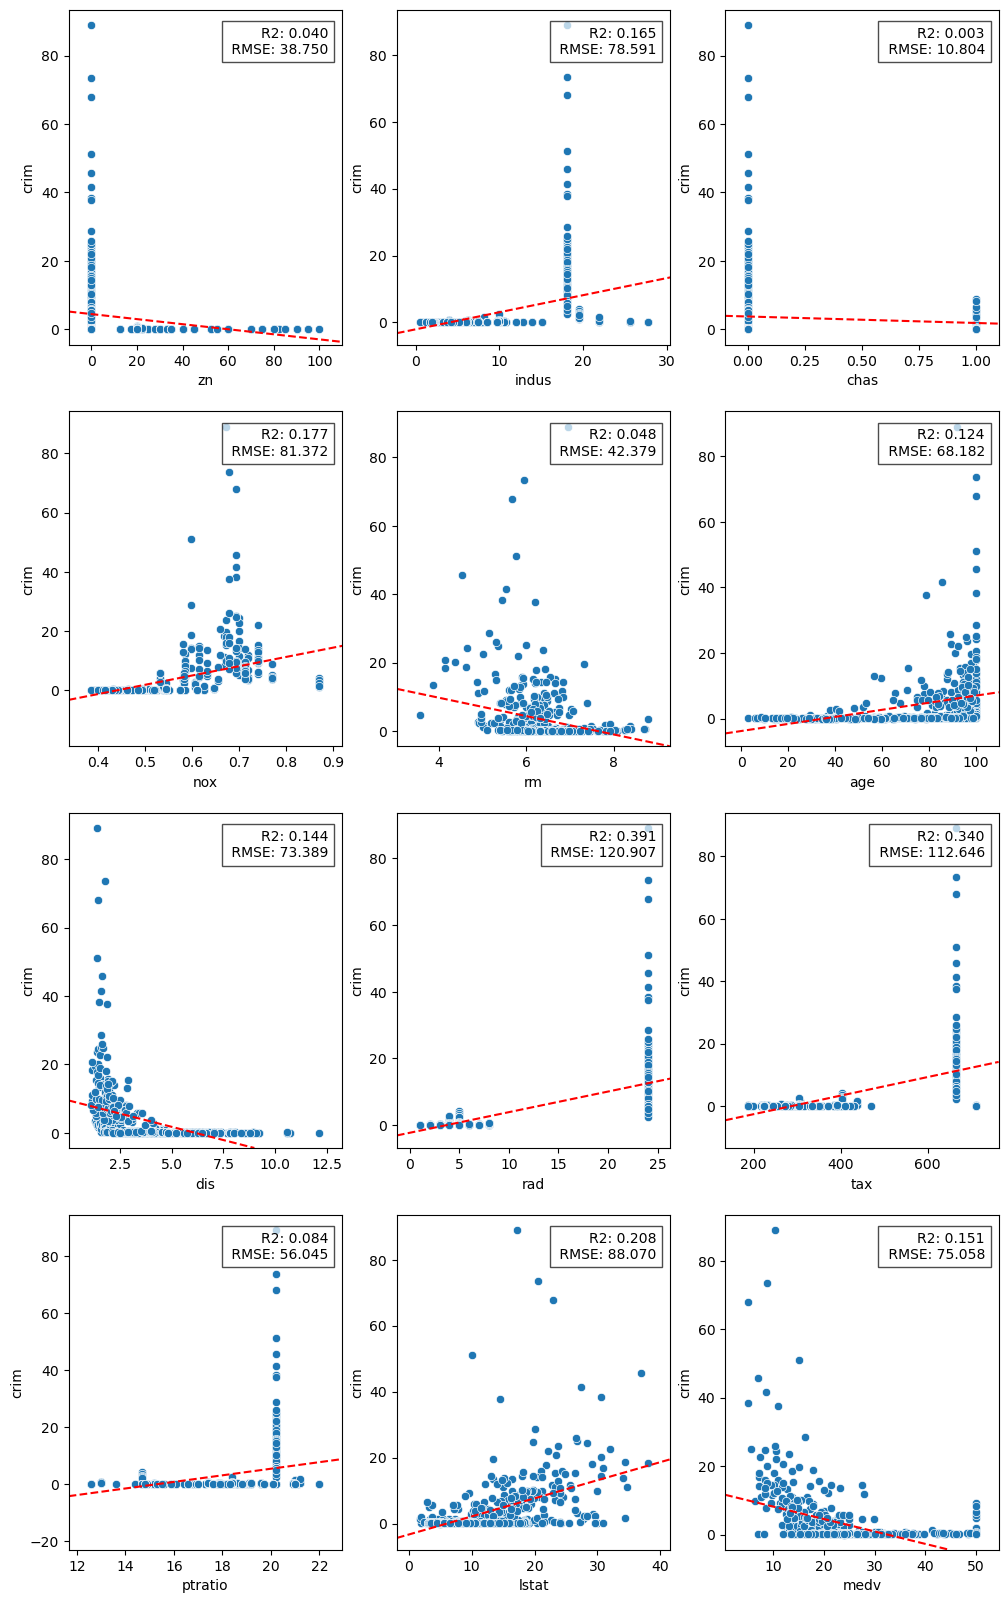

In [5]:
fig,ax = subplots(4,3,figsize=(12,20))
ax = ax.flatten()
for i,predictor in enumerate(one_var_models):
    model = one_var_models[predictor]
    sns.scatterplot(x=predictor,y='crim',data=boston,ax=ax[i])
    b0, b1 = model.params
    ax[i].text(0.95,0.95,'R2: {:.3f}\n RMSE: {:.3f}'.format(model.rsquared,np.sqrt(model.mse_model)),ha='right',va='top',transform=ax[i].transAxes,bbox={'facecolor':'white','alpha':0.7})
    ax[i].axline((0,b0),slope = b1,color='r',linestyle='--',label='Regression')
    xmin, xmax = boston[predictor].min(), boston[predictor].max()
    xrange = xmax-xmin
    ax[i].set_xlim(xmin-xrange/10,xmax+xrange/10)
plt.show()

## (b)
```{admonition}
:class: note
Fit a multiple regression model to predict the response using all of the predictors. For which predictors can we reject the null hypothesis $H_{0}: \beta_{j} = 0$?

In [6]:
model_all = smf.ols('crim ~ '+'+'.join(boston.columns[1:]), data=boston).fit()
print(summarize(model_all))

              coef  std err      t  P>|t|
Intercept  13.7784    7.082  1.946  0.052
zn          0.0457    0.019  2.433  0.015
indus      -0.0584    0.084 -0.698  0.486
chas       -0.8254    1.183 -0.697  0.486
nox        -9.9576    5.290 -1.882  0.060
rm          0.6289    0.607  1.036  0.301
age        -0.0008    0.018 -0.047  0.962
dis        -1.0122    0.282 -3.584  0.000
rad         0.6125    0.088  6.997  0.000
tax        -0.0038    0.005 -0.730  0.466
ptratio    -0.3041    0.186 -1.632  0.103
lstat       0.1388    0.076  1.833  0.067
medv       -0.2201    0.060 -3.678  0.000


In [7]:
rejectable = [pred for pred in model_all.params.index if model_all.pvalues.loc[pred]<0.05]
print(rejectable)

['zn', 'dis', 'rad', 'medv']


In [8]:
bonferroni_rejectable = [pred for pred in rejectable if model_all.pvalues.loc[pred]<0.05/(boston.shape[1]-1)]
print(bonferroni_rejectable)

['dis', 'rad', 'medv']


## (c)
```{admonition}
:class: note
How do your results from (a) compare to your results from (b)? Create a plot displaying the univariate regression coefficients from (a) on the x-axis, and the multiple regression coefficients from (b) on the y-axis. That is, each predictor is displayed as a single point in the plot. Its coefficient in a simple linear regression model is shown on the $x$-axis, and its coefficient estimate in the multiple linear regression model is shown on the $y$-axis.

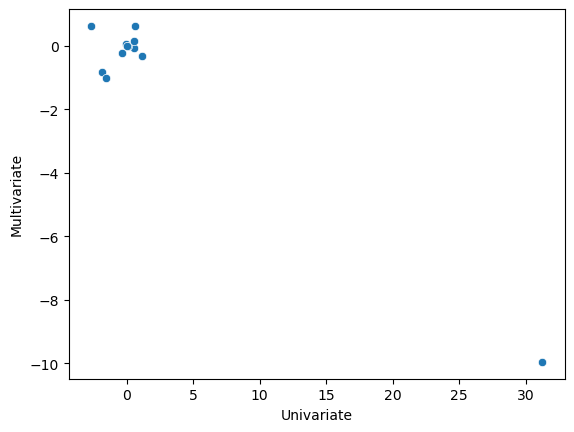

In [9]:
df = pd.concat([pd.Series({pred : one_var_models[pred].params.iloc[1] for pred in one_var_models}),model_all.params.drop('Intercept')],axis=1)
df.columns = ['Univariate','Multivariate']
sns.scatterplot(x='Univariate',y='Multivariate',data = df)
plt.show()

## (d)
```{admonition}
:class: note
Is there evidence of non-linear association between any of the predictors and the response? To answer this question, for each predictor $X$, fit a model of the form
$$
Y = \beta_{0} + \beta_{1}X + \beta_{2}X^{2} + \beta_{3}X^{3} + \varepsilon.
$$

In [10]:
one_var_cubic_models = {}
for predictor in boston.columns[1:]:
    one_var_cubic_models[predictor] = smf.ols(formula = f'crim ~ {predictor}+I({predictor}**2)+I({predictor}**3)',data=boston).fit()
    print(f'Cubic model predicting crime rate using {predictor}')
    print(summarize(one_var_cubic_models[predictor]))
    print()

Cubic model predicting crime rate using zn
                coef   std err       t  P>|t|
Intercept   4.846100  0.433000  11.192  0.000
zn         -0.332200  0.110000  -3.025  0.003
I(zn ** 2)  0.006500  0.004000   1.679  0.094
I(zn ** 3) -0.000038  0.000031  -1.203  0.230

Cubic model predicting crime rate using indus
                 coef  std err      t  P>|t|
Intercept      3.6626    1.574  2.327   0.02
indus         -1.9652    0.482 -4.077   0.00
I(indus ** 2)  0.2519    0.039  6.407   0.00
I(indus ** 3) -0.0070    0.001 -7.292   0.00

Cubic model predicting crime rate using chas
                coef  std err      t  P>|t|
Intercept     3.7444    0.396  9.453  0.000
chas         -0.6309    0.502 -1.257  0.209
I(chas ** 2) -0.6309    0.502 -1.257  0.209
I(chas ** 3) -0.6309    0.502 -1.257  0.209

Cubic model predicting crime rate using nox
                  coef  std err      t  P>|t|
Intercept     233.0866   33.643  6.928    0.0
nox         -1279.3713  170.397 -7.508    0.0
I(nox 